In [ ]:
!pip install igraph
import igraph as ig

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 13.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import networkx as nx
from networkx.algorithms import community
import community as community_louvain
import matplotlib.pyplot as plt
import igraph as ig
%matplotlib inline

In [ ]:
G = nx.karate_club_graph()

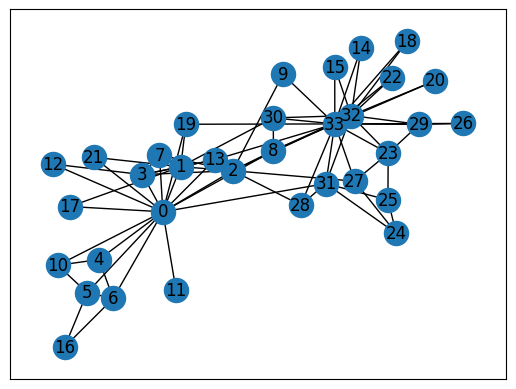

In [ ]:
# Define the graph G
G = nx.karate_club_graph()

# Draw the graph
nx.draw_networkx(G)

# Community Algorithms

## Edge betweenness (Girvan–Newman)

In [ ]:
lst_b = nx.algorithms.community.girvan_newman(G)
type(lst_b)

generator

In [ ]:
for x in lst_b:
  print(x)

({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})
({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}, {9})
({0, 1, 3, 7, 11, 12, 13, 17, 19, 21}, {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}, {4, 5, 6, 10, 16}, {9})
({0, 1, 3, 7, 11, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}, {9})
({0, 1, 3, 7, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}, {9}, {11})
({0, 1, 3, 7, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 29, 30}, {9}, {11}, {26})
({0, 1, 3, 7, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 29, 30}, {9}, {11}, {12}, {26})
({0, 1, 3, 7, 13, 17, 19, 21}, {2, 24, 25

1


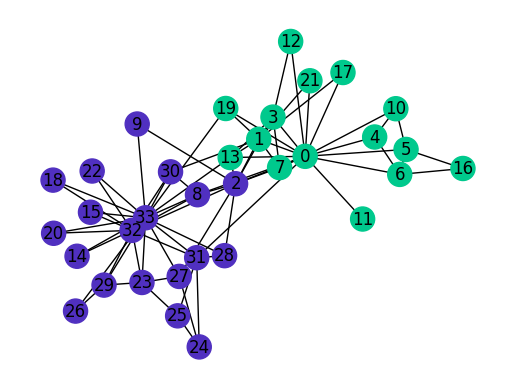

In [ ]:
colors = ["#00C98D", "#5030C0", "#50F0F0"]
pos = nx.spring_layout(G)
lst_b = community.girvan_newman(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values
counter = 0
for x in lst_b:
  print(1)
  for c in x:
    for n in c:
      color_map_b[n] = colors[counter]
    counter = counter + 1
  break
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()

In [ ]:
modularity = []
for x in lst_b:
  modularity.append(community.modularity(G, x))
modularity

[0.3423192968647514,
 0.3580611307884035,
 0.3849721706864564,
 0.37578006409175235,
 0.3594760218136841,
 0.3470699574595678,
 0.33324900208017094,
 0.31344052772624204,
 0.3122598901819681,
 0.30368621277712193,
 0.29429733325837226,
 0.28271584115739956,
 0.27116245947414774,
 0.2544648713479881,
 0.23975375274076566,
 0.2268979217031164,
 0.22299057363992417,
 0.20056783043796028,
 0.18696238826108952,
 0.1609134011731414,
 0.1428102921609415,
 0.11768894885778003,
 0.11088622776934465,
 0.10076647738985402,
 0.08837915331421826,
 0.0562395757200952,
 0.04398343359382321,
 0.011515901126290735,
 -0.0035044320758606464,
 -0.03105264144225183,
 -0.04655085174565694,
 -0.05110473941642772]

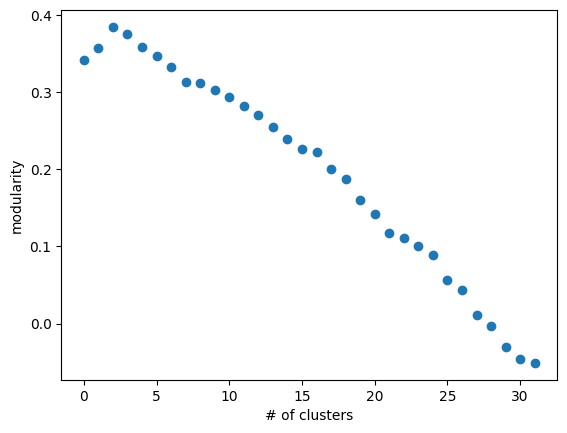

In [ ]:
plt.plot(modularity, 'o')
plt.xlabel('# of clusters')
plt.ylabel('modularity')
plt.show()

In [ ]:
max_modularity = max(modularity)
max_community = None

for community, mod_value in zip(lst_b, modularity):
    if mod_value == max_modularity:
        max_community = community
        break  # Stop after finding the maximum modularity community

if max_community:
    # Community visualization for the max_community
    colors = ["#00C98D", "#5030C0", "#50F0F0", 'red', 'blue']
    pos = nx.spring_layout(G)
    color_map_b = {}
    keys = G.nodes()
    values = "black"
    for i in keys:
        color_map_b[i] = values
    counter = 0
    for x in max_community:
        for n in x:
            color_map_b[n] = colors[counter]
        counter = counter + 1

    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
    nx.draw_networkx_labels(G, pos)
    plt.axis("off")
    plt.show()
else:
    print("No community found with maximum modularity.")


No community found with maximum modularity.


## Modularity maximization

In [ ]:
community.greedy_modularity_communities(G)

[frozenset({8,
            14,
            15,
            18,
            20,
            22,
            23,
            24,
            25,
            26,
            27,
            28,
            29,
            30,
            31,
            32,
            33}),
 frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21}),
 frozenset({0, 4, 5, 6, 10, 11, 16, 19})]

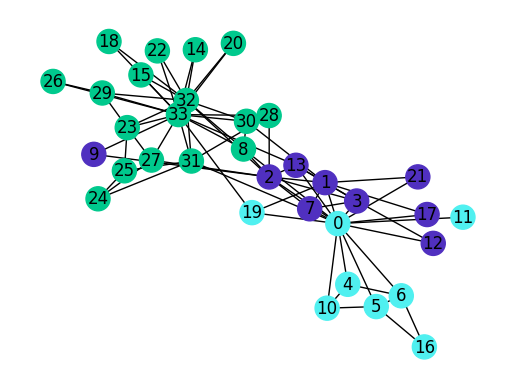

In [ ]:
#Community visualization
colors = ["#00C98D", "#5030C0", "#50F0F0"]
pos = nx.spring_layout(G)
lst_b = community.greedy_modularity_communities(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values
counter = 0
for x in lst_b:
  for n in x:
    color_map_b[n] = colors[counter]
  counter = counter + 1

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()

## Label propagation

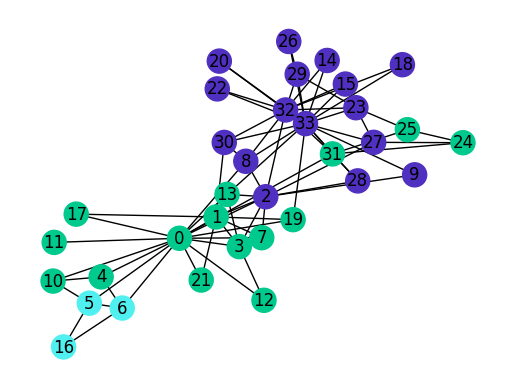

In [ ]:
colors = ["#00C98D", "#5030C0", "#50F0F0"]
pos = nx.spring_layout(G)
lst_m = community.label_propagation_communities(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values
counter = 0
for c in lst_m:
  for n in c:
    color_map_b[n] = colors[counter]
  counter = counter + 1
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()

## Fast community unfolding (Louvian)

Local moving of nodes: In this phase, each node is moved to the community that results in the highest increase in modularity. The node will remain in the same community if there is no positive gain. This process is applied repeatedly and for all nodes until no further improvement is possible. The first phase of the Louvain algorithm stops when a local maximum of modularity is obtained.


Building a new network: In this phase, the algorithm builds a new network considering communities found in the first phase as nodes. The weights of the links between communities are the sum of the weights of the links between their nodes. Once the second phase is completed, the algorithm will reapply the first phase to the resulting network. These steps are repeated until there are no changes in the network and maximum modularity is obtained


In [ ]:
!pip install community

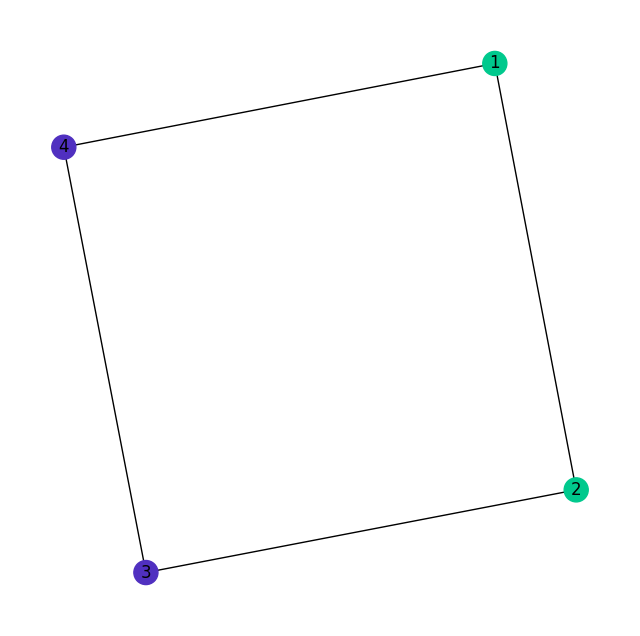

In [ ]:
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt

# Assuming G is defined and has nodes and edges added to it
G = nx.Graph()

# Generate a sample graph for demonstration
G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])

colors = ["#00C98D", "#5030C0", "#50F0F0", 'yellow']
pos = nx.spring_layout(G)
lst_m = community_louvain.best_partition(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values

for n in dict(lst_m):
  color_map_b[n] = colors[lst_m[n]]

plt.figure(figsize=(8, 8))  # Increase the figure size
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()


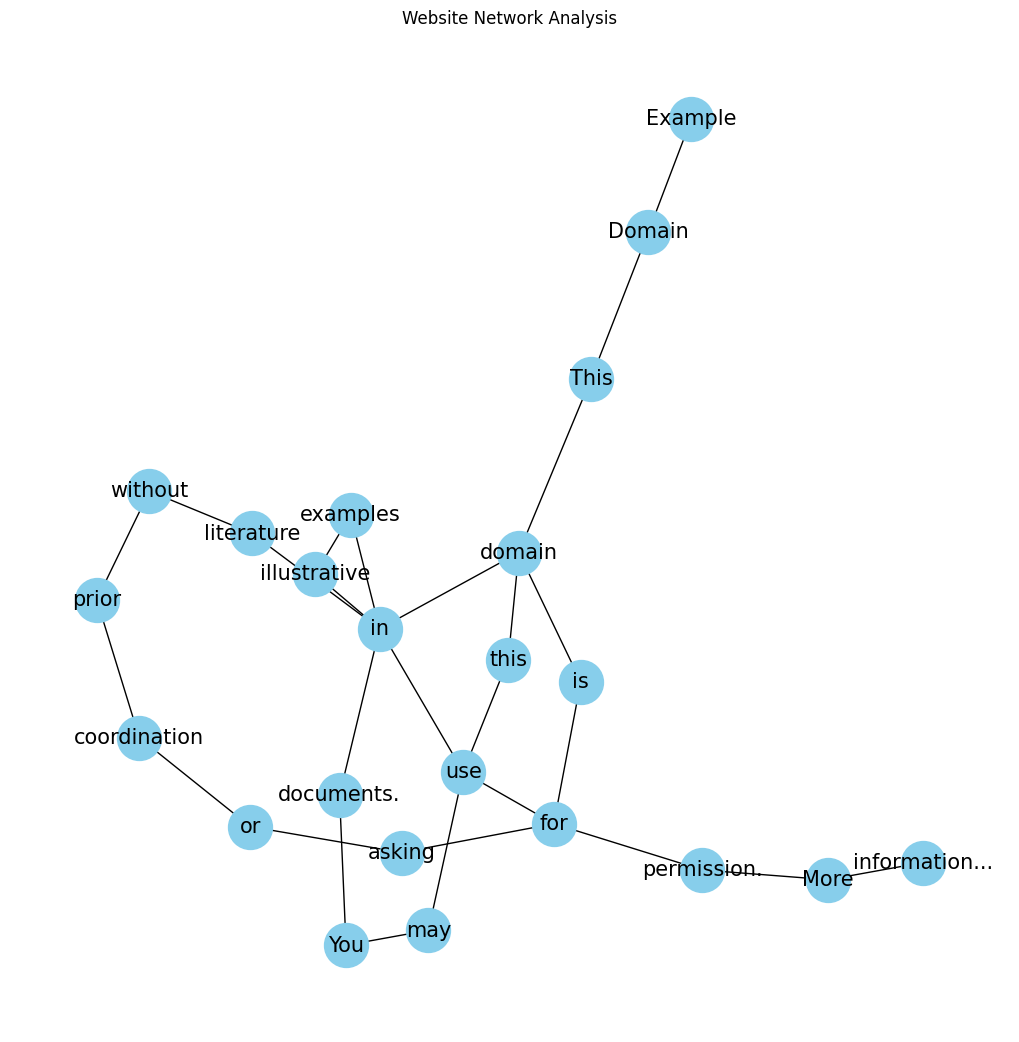

In [ ]:
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# Function to scrape data from a website
def scrape_website(url):
    try:
        response = requests.get(url)
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            # Extract relevant data from the website
            # Example: titles, links, text, etc.
            # For simplicity, let's extract text content
            text_content = soup.get_text()
            return text_content
        else:
            print("Failed to retrieve data from:", url)
            return None
    except Exception as e:
        print("Error occurred:", e)
        return None

# Main function for network analysis
def main():
    # Define the URL to scrape
    url = "https://example.com"

    # Scrape data from the website
    text_content = scrape_website(url)

    # If data is successfully scraped, perform network analysis
    if text_content:
        # Create a graph
        G = nx.Graph()

        # Process text content (you may need more advanced text processing here)
        # For simplicity, let's split text by whitespace
        words = text_content.split()

        # Add nodes and edges to the graph
        for i in range(len(words) - 1):
            word1 = words[i]
            word2 = words[i + 1]
            if not G.has_edge(word1, word2):
                G.add_edge(word1, word2)

        # Visualize the network
        pos = nx.spring_layout(G)
        plt.figure(figsize=(10, 10))
        nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, edge_color='black', linewidths=1, font_size=15)
        plt.title("Website Network Analysis")
        plt.show()
    else:
        print("Failed to scrape data. Exiting...")

if __name__ == "__main__":
    main()


In [ ]:
pip install Flask


## **final **

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 14.2 MB/s eta 0:00:00
({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})
({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}, {9})
({0, 1, 3, 7, 11, 12, 13, 17, 19, 21}, {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}, {4, 5, 6, 10, 16}, {9})
({0, 1, 3, 7, 11, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}, {9})
({0, 1, 3, 7, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}, {9}, {11})
({0, 1, 3, 7, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 29, 30}, {9}, {11}, {26})
({0, 1, 3, 7, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22

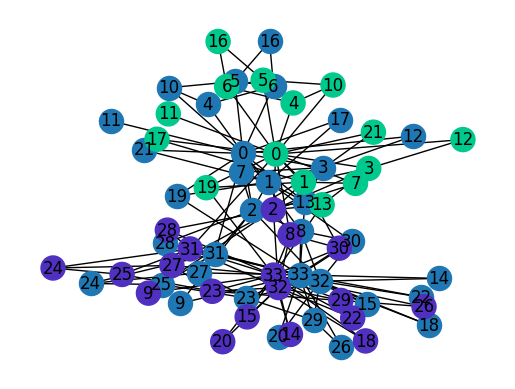

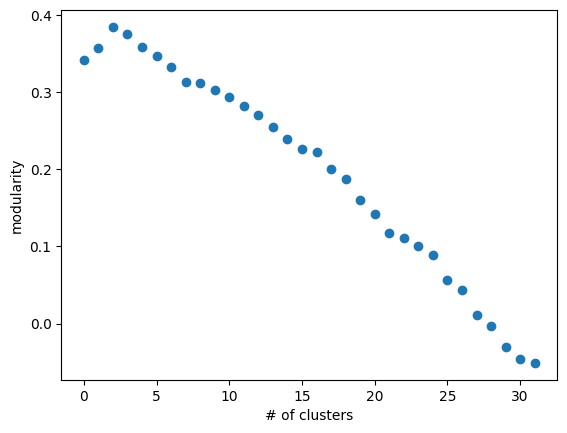

No community found with maximum modularity.


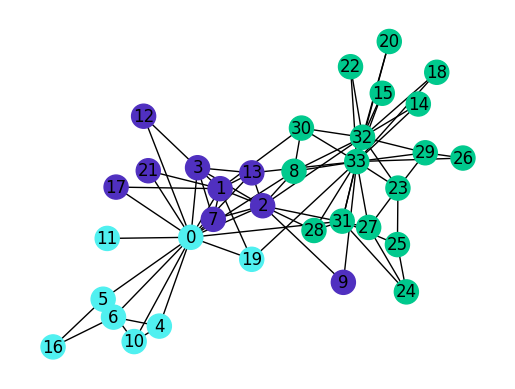

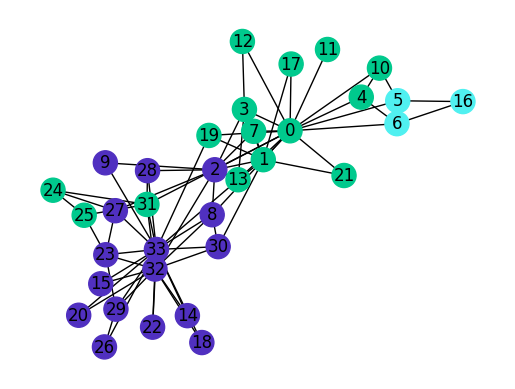

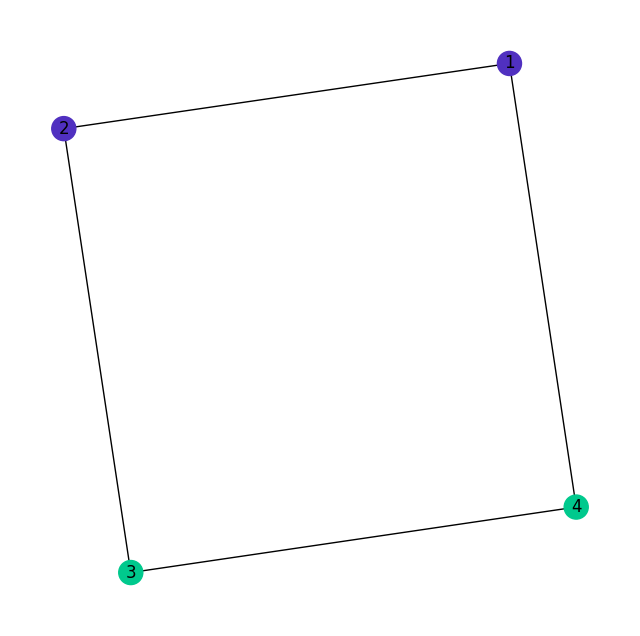

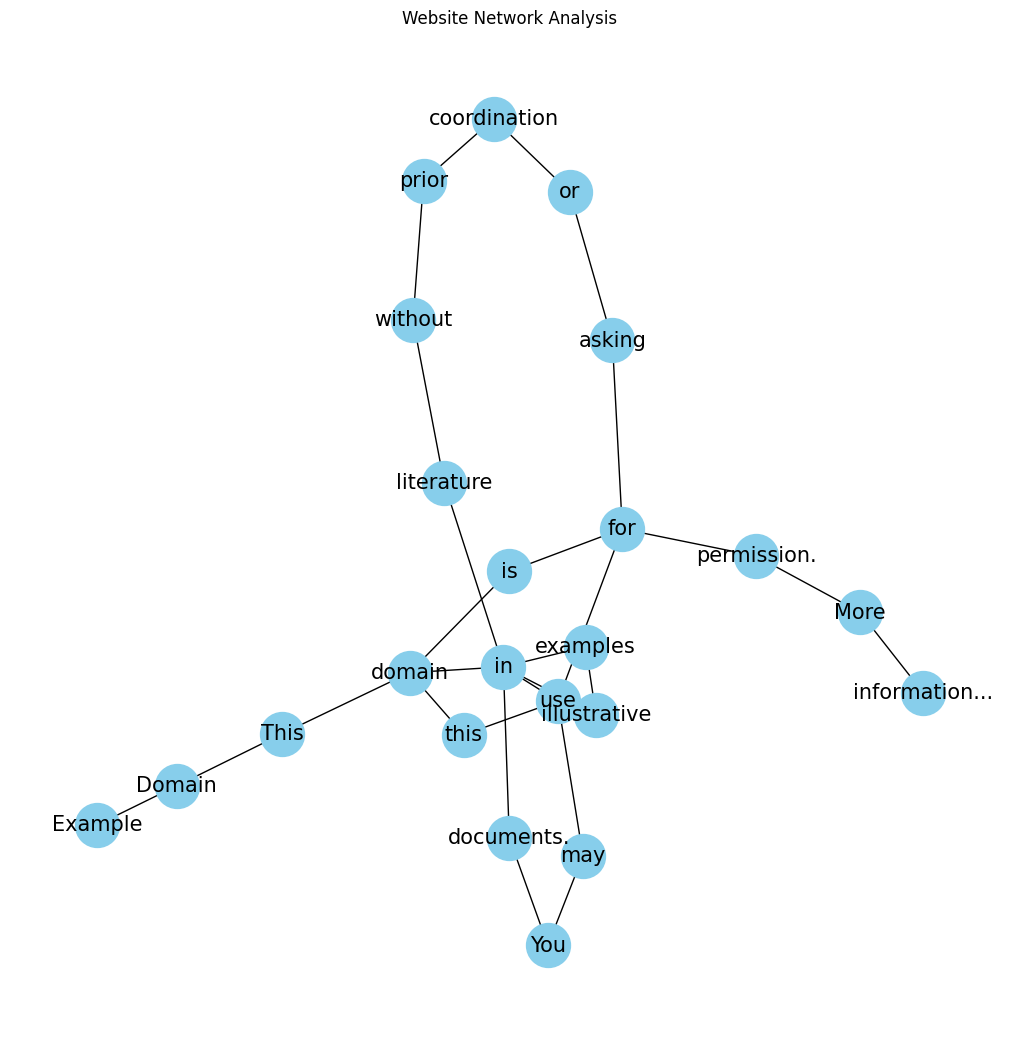

In [ ]:
!pip install igraph
import igraph as ig
import pandas as pd
import networkx as nx
from networkx.algorithms import community
import community as community_louvain
import matplotlib.pyplot as plt
import igraph as ig
%matplotlib inline
G = nx.karate_club_graph()
# Define the graph G
G = nx.karate_club_graph()

# Draw the graph
nx.draw_networkx(G)
lst_b = nx.algorithms.community.girvan_newman(G)
type(lst_b)
for x in lst_b:
  print(x)
colors = ["#00C98D", "#5030C0", "#50F0F0"]
pos = nx.spring_layout(G)
lst_b = community.girvan_newman(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values
counter = 0
for x in lst_b:
  print(1)
  for c in x:
    for n in c:
      color_map_b[n] = colors[counter]
    counter = counter + 1
  break
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()
modularity = []
for x in lst_b:
  modularity.append(community.modularity(G, x))
modularity
plt.plot(modularity, 'o')
plt.xlabel('# of clusters')
plt.ylabel('modularity')
plt.show()
max_modularity = max(modularity)
max_community = None

for community, mod_value in zip(lst_b, modularity):
    if mod_value == max_modularity:
        max_community = community
        break  # Stop after finding the maximum modularity community

if max_community:
    # Community visualization for the max_community
    colors = ["#00C98D", "#5030C0", "#50F0F0", 'red', 'blue']
    pos = nx.spring_layout(G)
    color_map_b = {}
    keys = G.nodes()
    values = "black"
    for i in keys:
        color_map_b[i] = values
    counter = 0
    for x in max_community:
        for n in x:
            color_map_b[n] = colors[counter]
        counter = counter + 1

    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
    nx.draw_networkx_labels(G, pos)
    plt.axis("off")
    plt.show()
else:
    print("No community found with maximum modularity.")
community.greedy_modularity_communities(G)
#Community visualization
colors = ["#00C98D", "#5030C0", "#50F0F0"]
pos = nx.spring_layout(G)
lst_b = community.greedy_modularity_communities(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values
counter = 0
for x in lst_b:
  for n in x:
    color_map_b[n] = colors[counter]
  counter = counter + 1

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()
colors = ["#00C98D", "#5030C0", "#50F0F0"]
pos = nx.spring_layout(G)
lst_m = community.label_propagation_communities(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values
counter = 0
for c in lst_m:
  for n in c:
    color_map_b[n] = colors[counter]
  counter = counter + 1
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()
!pip install community
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt

# Assuming G is defined and has nodes and edges added to it
G = nx.Graph()

# Generate a sample graph for demonstration
G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])

colors = ["#00C98D", "#5030C0", "#50F0F0", 'yellow']
pos = nx.spring_layout(G)
lst_m = community_louvain.best_partition(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values

for n in dict(lst_m):
  color_map_b[n] = colors[lst_m[n]]

plt.figure(figsize=(8, 8))  # Increase the figure size
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_nodes(G, pos, node_color=dict(color_map_b).values())
nx.draw_networkx_labels(G, pos)
plt.axis("off")
plt.show()

import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# Function to scrape data from a website
def scrape_website(url):
    try:
        response = requests.get(url)
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            # Extract relevant data from the website
            # Example: titles, links, text, etc.
            # For simplicity, let's extract text content
            text_content = soup.get_text()
            return text_content
        else:
            print("Failed to retrieve data from:", url)
            return None
    except Exception as e:
        print("Error occurred:", e)
        return None

# Main function for network analysis
def main():
    # Define the URL to scrape
    url = "https://example.com"

    # Scrape data from the website
    text_content = scrape_website(url)

    # If data is successfully scraped, perform network analysis
    if text_content:
        # Create a graph
        G = nx.Graph()

        # Process text content (you may need more advanced text processing here)
        # For simplicity, let's split text by whitespace
        words = text_content.split()

        # Add nodes and edges to the graph
        for i in range(len(words) - 1):
            word1 = words[i]
            word2 = words[i + 1]
            if not G.has_edge(word1, word2):
                G.add_edge(word1, word2)

        # Visualize the network
        pos = nx.spring_layout(G)
        plt.figure(figsize=(10, 10))
        nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, edge_color='black', linewidths=1, font_size=15)
        plt.title("Website Network Analysis")
        plt.show()
    else:
        print("Failed to scrape data. Exiting...")

if __name__ == "__main__":
    main()


F1 Score: 0.3333333333333333


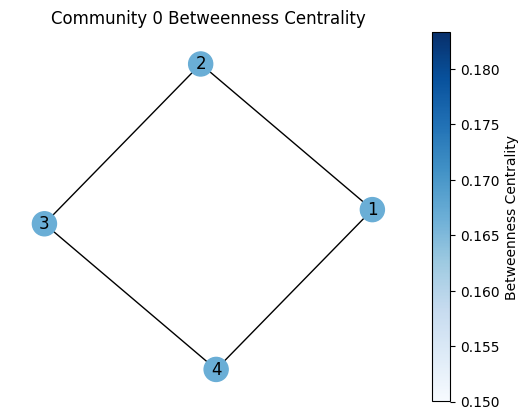

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from networkx.algorithms import community

# Assuming G is defined and has nodes and edges added to it
G = nx.Graph()

# Generate a sample graph for demonstration
G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])

colors = ["#00C98D", "#5030C0", "#50F0F0", 'yellow']
pos = nx.spring_layout(G)
lst_m = community.greedy_modularity_communities(G)
color_map_b = {}
keys = G.nodes()
values = "black"
for i in keys:
        color_map_b[i] = values

# Assuming ground truth labels are available
ground_truth_labels = {1: 0, 2: 0, 3: 1, 4: 1}  # Example ground truth labels

predicted_labels = []
for node in G.nodes():
    for i, community in enumerate(lst_m):
        if node in community:
            predicted_labels.append(i)
            break

# Calculate F1 score
f1 = f1_score(list(ground_truth_labels.values()), predicted_labels, average='weighted')

print("F1 Score:", f1)

# Calculate betweenness centrality for each node within each community
betweenness_centralities = {}
for i, community in enumerate(lst_m):
    community_subgraph = G.subgraph(community)
    betweenness_centralities[i] = nx.betweenness_centrality(community_subgraph)

# Visualize the betweenness centrality for nodes within each community
for i, community in enumerate(lst_m):
    community_subgraph = G.subgraph(community)
    node_colors = [betweenness_centralities[i][node] for node in community_subgraph.nodes()]
    nx.draw_networkx_edges(G, pos)
    # Use plt.scatter() to create nodes and get a mappable object
    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Blues)
    nx.draw_networkx_labels(G, pos)
    plt.title(f"Community {i} Betweenness Centrality")
    # Create colorbar using the mappable object returned by plt.scatter()
    plt.colorbar(nodes, label='Betweenness Centrality')
    plt.axis("off")
    plt.show()


# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

# Identify anomalies based on centrality measures (you can adjust the threshold as needed)
degree_threshold = 2 * sum(degree_centrality.values()) / len(degree_centrality)
betweenness_threshold = 2 * sum(betweenness_centrality.values()) / len(betweenness_centrality)
eigenvector_threshold = 2 * sum(eigenvector_centrality.values()) / len(eigenvector_centrality)

anomaly_nodes = []
for node in G.nodes():
    if degree_centrality[node] > degree_threshold or \
       betweenness_centrality[node] > betweenness_threshold or \
       eigenvector_centrality[node] > eigenvector_threshold:
        anomaly_nodes.append(node)

# Draw the graph with anomalies highlighted
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)

# Draw normal nodes
nx.draw(G, pos, nodelist=[n for n in G.nodes() if n not in anomaly_nodes],
        with_labels=True, node_color='skyblue', node_size=1000,
        edge_color='black', linewidths=1, font_size=15)

# Draw anomaly nodes with different color and larger size
nx.draw_networkx_nodes(G, pos, nodelist=anomaly_nodes, node_color='red', node_size=2000)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.title("Network Graph with Anomalies")
plt.show()


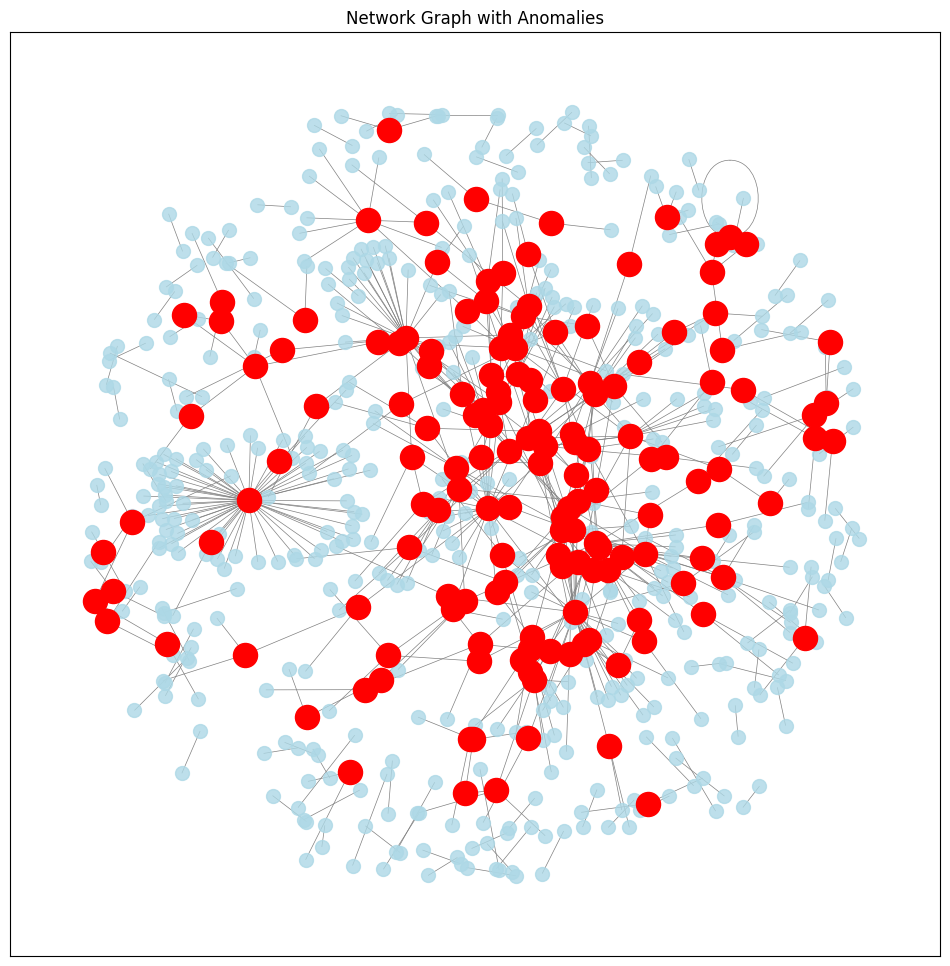

F1 Score: 0.0
Anomalies:
                   Degree Centrality
battlefield_4               0.086957
fitnesscirclejerk           0.016103
lifeprotips                 0.003221
soccer                      0.009662
bestoftldr                  0.004831
...                              ...
anal                        0.003221
colts                       0.003221
bsg                         0.003221
tangents                    0.003221
NaN                         0.003221

[154 rows x 1 columns]


In [ ]:
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
%matplotlib inline

# Read the dataset from the provided path
dataset_path = "/content/Dataset.csv"
df = pd.read_csv(dataset_path)

# Assuming the dataset contains columns 'source_node' and 'target_node' representing edges
# If your dataset has different column names, please replace them accordingly
G = nx.from_pandas_edgelist(df, 'source_node', 'target_node')

# Anomaly Detection using Degree Centrality
degree_centrality = nx.degree_centrality(G)

# Compute mean and standard deviation of degree centrality
mean_degree_centrality = sum(degree_centrality.values()) / len(degree_centrality)
std_degree_centrality = sum([(x - mean_degree_centrality) ** 2 for x in degree_centrality.values()]) / len(degree_centrality)
threshold = mean_degree_centrality + 2 * std_degree_centrality

# Identify anomalies
anomalies = {node: centrality for node, centrality in degree_centrality.items() if centrality > threshold}

# Draw the graph with adjusted parameters
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15)  # Adjust 'k' to increase spacing between clusters

# Draw edges with reduced width and gray color
nx.draw_networkx_edges(G, pos, edge_color='gray', width=0.5)

# Draw normal nodes with reduced size and light blue color
nx.draw_networkx_nodes(G, pos, nodelist=[node for node in G.nodes() if node not in anomalies],
                       node_color='lightblue', node_size=100, alpha=0.8)

# Highlight anomalies in red
nx.draw_networkx_nodes(G, pos, nodelist=anomalies.keys(), node_color='red', node_size=300)

# Hide node labels
nx.draw_networkx_labels(G, pos, labels={}, font_size=12)

plt.title("Network Graph with Anomalies")
plt.show()

# Convert anomalies to a DataFrame for easier analysis
anomalies_df = pd.DataFrame.from_dict(anomalies, orient='index', columns=['Degree Centrality'])

# Calculate F1 score (assuming you have ground truth for anomalies)
# ground_truth_anomalies should be a dictionary with node IDs as keys and anomaly labels as values
# For example: ground_truth_anomalies = {'node1': 1, 'node2': 0, ...}
# Adjust the threshold as needed based on your data and requirements
ground_truth_anomalies = {}  # Replace with actual ground truth if available
predicted_anomalies = {node: 1 if centrality > threshold else 0 for node, centrality in degree_centrality.items()}
y_true = [ground_truth_anomalies.get(node, 0) for node in G.nodes()]
y_pred = [predicted_anomalies.get(node, 0) for node in G.nodes()]
f1score = f1_score(y_true, y_pred)

print("F1 Score:", f1score)
print("Anomalies:")
print(anomalies_df)


In [ ]:
import pandas as pd
import networkx as nx
from sklearn.metrics import precision_score, recall_score, f1_score
from networkx.algorithms import community as nx_comm

# Read the dataset
dataset = {
    'SOURCE_SUBREDDIT': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'TARGET_SUBREDDIT': ['B', 'C', 'D', 'A', 'F', 'G', 'H', 'E'],
    'Ground_Truth_Community': [0, 0, 1, 1, 2, 2, 3, 3]  # Example ground truth labels
}

# Convert dataset to DataFrame
df = pd.DataFrame(dataset)

# Create Graph
G = nx.from_pandas_edgelist(df, 'SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT')

# Ground truth labels
ground_truth_labels = dict(zip(df['SOURCE_SUBREDDIT'], df['Ground_Truth_Community']))

# Community detection
lst_m = list(nx_comm.greedy_modularity_communities(G))

# Louvain modularity
partition = nx_comm.greedy_modularity_communities(G)

# Betweenness centrality
betweenness_centralities = nx.betweenness_centrality(G)

# Convert Louvain partition to node-community mapping
louvain_labels = {}
for i, comm in enumerate(partition):
    for node in comm:
        louvain_labels[node] = i

# Calculate precision, recall, and F1 score for each method
precision_community = precision_score(list(ground_truth_labels.values()), [ground_truth_labels[node] for node in G.nodes()], average='weighted')
recall_community = recall_score(list(ground_truth_labels.values()), [ground_truth_labels[node] for node in G.nodes()], average='weighted')
f1_community = f1_score(list(ground_truth_labels.values()), [ground_truth_labels[node] for node in G.nodes()], average='weighted')

precision_louvain = precision_score(list(ground_truth_labels.values()), [louvain_labels[node] for node in G.nodes()], average='weighted')
recall_louvain = recall_score(list(ground_truth_labels.values()), [louvain_labels[node] for node in G.nodes()], average='weighted')
f1_louvain = f1_score(list(ground_truth_labels.values()), [louvain_labels[node] for node in G.nodes()], average='weighted')

# Convert betweenness centrality scores to subreddit labels
betweenness_labels = {subreddit: max(betweenness_centralities, key=betweenness_centralities.get) for subreddit in ground_truth_labels.keys()}

# Calculate precision, recall, and F1 score for betweenness centrality
precision_betweenness = precision_score(list(ground_truth_labels.values()), [ground_truth_labels[node] for node in betweenness_labels.keys()], average='weighted')
recall_betweenness = recall_score(list(ground_truth_labels.values()), [ground_truth_labels[node] for node in betweenness_labels.keys()], average='weighted')
f1_betweenness = f1_score(list(ground_truth_labels.values()), [ground_truth_labels[node] for node in betweenness_labels.keys()], average='weighted')

# Tabulate the results
results = pd.DataFrame({
    'Method': ['Community Detection', 'Louvain Modularity', 'Betweenness Centrality'],
    'Precision': [precision_community, precision_louvain, precision_betweenness],
    'Recall': [recall_community, recall_louvain, recall_betweenness],
    'F1 Score': [f1_community, f1_louvain, f1_betweenness]
})

print(results)


                   Method  Precision  Recall  F1 Score
0     Community Detection      1.000    1.00  1.000000
1      Louvain Modularity      0.125    0.25  0.166667
2  Betweenness Centrality      1.000    1.00  1.000000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
